##### Imports

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path

from gg570_d200.auxiliary_functions.synthetic_funcs import synthetic_loop, prepare_heatmap, plot_heatmap
from gg570_d200.auxiliary_functions.overlap_funcs import overlap_measures

In [10]:
root = Path.cwd().parent
data_path = root / "data"

---

##### Synthetic measures

###### Set-up

In [11]:
np.random.seed(21)

In [12]:
df_scaled = pd.read_csv(data_path / "df_scaled.csv")

In [13]:
treatment_col = 'Training (last 3 months)'
outcome_col = 'Underemployment hours'
covariate_cols = [col for col in df_scaled.columns if col not in treatment_col and col not in outcome_col and col not in ['prop_scores']]

In [14]:
true_extreme_scores_perc, true_ess_perc = overlap_measures(df_scaled, treatment_col, 'prop_scores')

###### Loop

In [15]:
iterations = 400
synthetic_ate = 10 # Chosen arbitrarily. Close to the mean of the outcome variable in the original data.

In [16]:
iterations_dict = synthetic_loop(df_scaled, covariate_cols, iterations, synthetic_ate, root, cross_validate=True)

1
40
80
120
160
200
240
280
320
360
399


In [20]:
bins_per_overlap_measure = 4

In [21]:
data_matrix, str_matrix, true_bin_i, true_bin_j, extreme_scores_categories, ess_categories = prepare_heatmap(iterations_dict, synthetic_ate, true_extreme_scores_perc, true_ess_perc, bins_per_overlap_measure)

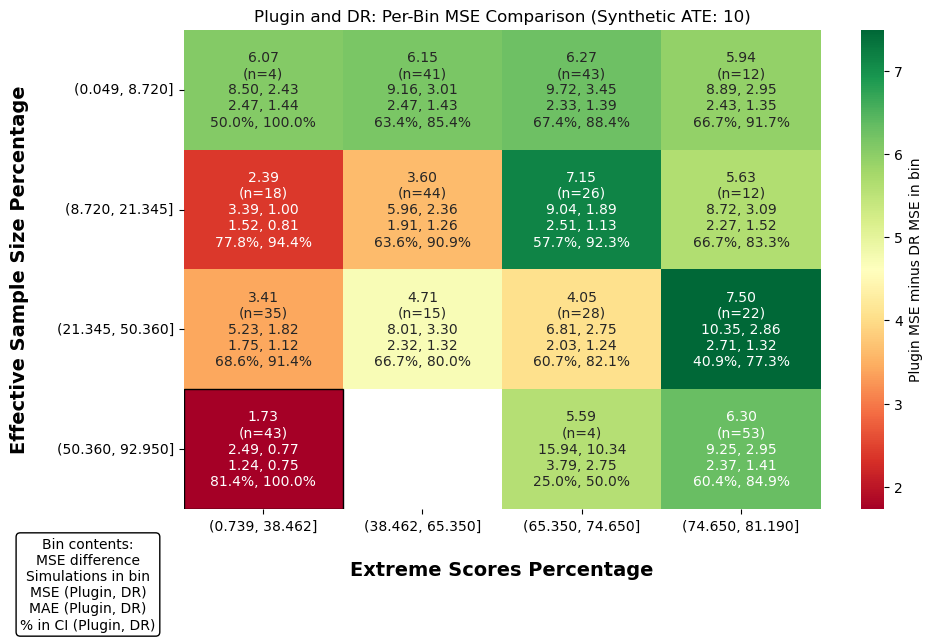

In [22]:
plot_heatmap(data_matrix, str_matrix, true_bin_i, true_bin_j, extreme_scores_categories, ess_categories, synthetic_ate, root)